In [110]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [111]:
skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")


In [150]:
skolky_venkov = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_venkov.parquet")
skolky_venkov["kombinace"]=skolky_venkov["kombinace"]=2
skolky_mesto = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/interpolated_skolky_mesto.parquet")
skolky_mesto["kombinace"]=skolky_mesto["kombinace"]=1
skolky_mesto.loc[skolky_mesto["Název_ORP"] == "Hlavní město Praha", "kombinace"] = 3

skolky_body = pd.concat(
    [skolky_venkov, skolky_mesto]
)
skolky_body=skolky_body.drop(columns=["index_right"])

In [151]:
obce_polygony = gpd.read_file("geometrie/OBCE_SILC.shp").to_crs(5514)
obce_polygony

,KOD_OBEC,NAZ_OBEC,KOD_KRAJ_2,KOD_KRAJ,NAZ_KRAJ,OBLAST_KOD,OBLAST_TEX,TYP_TEXT,Shape_Leng,Shape_Area,TYP_KOD,geometry
0,500011,Želechovice nad Dřevnicí,CZ072,3131,Zlínský kraj,3,řídce obydlená,venkovské obce,24721.171080,1.618763e+07,4,"POLYGON ((-515672.8 -1166154.79, -515289.54 -1..."
1,500020,Petrov nad Desnou,CZ071,3123,Olomoucký kraj,3,řídce obydlená,venkovské obce,15228.386594,1.204318e+07,4,"POLYGON ((-555733.68 -1072434.02, -555222.81 -..."
2,500046,Libhošť,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,14023.927023,8.130200e+06,4,"POLYGON ((-488317.45 -1121797.92, -488065.28 -..."
3,500062,Krhová,CZ072,3131,Zlínský kraj,2,středně obydlená,venkovské obce,13364.730297,8.156758e+06,4,"POLYGON ((-491776.64 -1137779.95, -492258.61 -..."
4,500071,Poličná,CZ072,3131,Zlínský kraj,2,středně obydlená,venkovské obce,21905.756085,1.102793e+07,4,"POLYGON ((-497702.34 -1138897.67, -497859.83 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...
6253,599930,Suchdol nad Odrou,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,24085.896424,2.292587e+07,4,"POLYGON ((-497583.25 -1116497.55, -497143.18 -..."
6254,599948,Štramberk,CZ080,3140,Moravskoslezský kraj,2,středně obydlená,venkovské obce,16111.755083,9.437697e+06,4,"POLYGON ((-485951.64 -1125945.1, -485876.96 -1..."
6255,599956,Tichá,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,19000.327499,1.652153e+07,4,"POLYGON ((-477355.33 -1127934.91, -477309.19 -..."
6256,599964,Tísek,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,14127.509258,8.090161e+06,4,"POLYGON ((-490709.98 -1103385.44, -490163.47 -..."


In [152]:
skolky_body["monthly_fe"].notna().sum()

np.int64(4787)

In [153]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [154]:
obce_skolky= gpd.sjoin(skolky_body,obce_polygony[["geometry","count"]])
#obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [156]:
obce_skolky

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry,KOD_OBEC,NAZ_OBEC,...,NAZ_KRAJ,OBLAST_KOD,OBLAST_TEX,TYP_TEXT,Shape_Leng,Shape_Area,TYP_KOD,kombinace,index_right,count
RED_IZO,,,,,,,,,,,,,,,,,,,,,
600041484.0,2.0,Středočeský kraj,Benešov,2101.0,https://www.mspetroupim.cz,"Mateřská škola Petroupim, okres Benešov",459.511167,POINT (-723351.135 -1077219.799),530409,Petroupim,...,Středočeský kraj,3,řídce obydlená,venkovské obce,18981.000508,9.718722e+06,4,2,386,1.0
600041581.0,2.0,Středočeský kraj,Vlašim,2125.0,None,"Mateřská škola, Křivsoudov",355.020918,POINT (-701505.318 -1099687.526),530000,Křivsoudov,...,Středočeský kraj,3,řídce obydlená,venkovské obce,21350.951164,1.357938e+07,4,2,348,1.0
600041620.0,2.0,Středočeský kraj,Benešov,2101.0,https://www.msnetvorice.cz,"Mateřská škola Netvořice, okres Benešov, přísp...",431.932574,POINT (-739881.288 -1073852.343),530298,Netvořice,...,Středočeský kraj,3,řídce obydlená,venkovské obce,28141.496602,1.772263e+07,4,2,375,1.0
600041638.0,2.0,Středočeský kraj,Benešov,2101.0,http://www.msneveklov.cz,"Mateřská škola Neveklov, okres Benešov",457.756041,POINT (-739440.755 -1081232.25),530310,Neveklov,...,Středočeský kraj,3,řídce obydlená,venkovské obce,68970.326622,5.453139e+07,4,2,377,1.0
600041671.0,2.0,Středočeský kraj,Vlašim,2125.0,None,"Mateřská škola Pravonín, okres Benešov",337.957214,POINT (-711770.278 -1097691.687),530476,Pravonín,...,Středočeský kraj,3,řídce obydlená,venkovské obce,26255.371081,1.984328e+07,4,2,393,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691015201.0,2.0,Jihočeský kraj,Strakonice,3111.0,www.ms-spojaru.strakonice.eu,Mateřská škola Spojařů Strakonice,430.000000,POINT (-791998.831 -1128353.563),550787,Strakonice,...,Jihočeský kraj,2,středně obydlená,městské obce,42375.925607,3.444663e+07,3,1,2176,8.0
691015384.0,2.0,Ústecký kraj,Most,4209.0,https://www.1msmost.cz,"1. mateřská škola, Most, příspěvková organizace",700.000000,POINT (-791670.454 -989340.968),567027,Most,...,Ústecký kraj,1,hustě obydlená,městské obce,64778.546882,8.698118e+07,3,1,3469,4.0
691015783.0,2.0,Středočeský kraj,Říčany,2122.0,https://www.msvetrnik.ricany.cz,"Mateřská škola Větrník Říčany, příspěvková org...",1512.000000,POINT (-726322.45 -1054821.193),538728,Říčany,...,Středočeský kraj,2,středně obydlená,městské obce,34404.593197,2.595901e+07,3,1,1200,6.0


In [180]:
mestske = obce_skolky[(obce_skolky["kombinace"] == 1) | (obce_skolky["kombinace"] == 3)]
venkovske = obce_skolky[obce_skolky["kombinace"]==2]

In [181]:
kraje_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/kraje.geojson")
kraje_polygony = kraje_polygony.to_crs(5514)

In [182]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/ORP.geojson")
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

In [190]:
fee = mestske.loc[mestske["monthly_fe"].notna()]

table1 = pd.DataFrame({

'average_m': mestske.groupby('Název_ORP')['monthly_fe'].mean().round(),
'std_m': mestske.groupby('Název_ORP')['monthly_fe'].std().round()})

table1.sort_values('average_m', ascending=False)

,average_m,std_m
Název_ORP,,
Říčany,1506.0,7.0
Hlavní město Praha,1205.0,223.0
Tachov,1000.0,0.0
Šumperk,1000.0,0.0
Turnov,971.0,76.0
...,...,...
Znojmo,350.0,0.0
Frýdlant,350.0,NaN
Uherské Hradiště,349.0,95.0


In [191]:
fee = mestske.loc[mestske["monthly_fe"].notna()]

table2 = pd.DataFrame({

'average_m': mestske.groupby('Kraj')['monthly_fe'].mean().round(),
'std_m': mestske.groupby('Kraj')['monthly_fe'].std().round()})

table2.sort_values('average_m', ascending=False)

,average_m,std_m
Kraj,,
Hlavní město Praha,1205.0,223.0
Jihomoravský kraj,791.0,180.0
Liberecký kraj,766.0,150.0
Středočeský kraj,766.0,226.0
Plzeňský kraj,700.0,131.0
Kraj Vysočina,676.0,136.0
Olomoucký kraj,647.0,110.0
Pardubický kraj,640.0,155.0
Moravskoslezský kraj,621.0,188.0


In [192]:
fee = venkovske.loc[venkovske["monthly_fe"].notna()]

table3 = pd.DataFrame({

'average_v': venkovske.groupby('Název_ORP')['monthly_fe'].mean().round(),
'std_v': venkovske.groupby('Název_ORP')['monthly_fe'].std().round()})

table3.sort_values('average_v', ascending=False)

,average_v,std_v
Název_ORP,,
Říčany,1086.0,284.0
Brandýs nad Labem-Stará Boleslav,1048.0,330.0
Český Brod,994.0,218.0
Černošice,842.0,159.0
Karviná,783.0,323.0
...,...,...
Bystřice nad Pernštejnem,229.0,40.0
Konice,221.0,108.0
Podbořany,204.0,215.0


In [193]:
fee = venkovske.loc[venkovske["monthly_fe"].notna()]

table4 = pd.DataFrame({

'average_v': venkovske.groupby('Kraj')['monthly_fe'].mean().round(),
'std_v': venkovske.groupby('Kraj')['monthly_fe'].std().round()})

table4.sort_values('average_v', ascending=False)

,average_v,std_v
Kraj,,
Středočeský kraj,655.0,268.0
Liberecký kraj,466.0,117.0
Jihomoravský kraj,435.0,134.0
Plzeňský kraj,434.0,124.0
Ústecký kraj,433.0,173.0
Zlínský kraj,418.0,94.0
Královéhradecký kraj,416.0,99.0
Moravskoslezský kraj,408.0,170.0
Karlovarský kraj,395.0,123.0


In [194]:
orp_m = orp_polygony.merge(table1, left_on ="naz_orp_p", right_index=True)
orp_v = orp_polygony.merge(table3, left_on ="naz_orp_p", right_index=True)



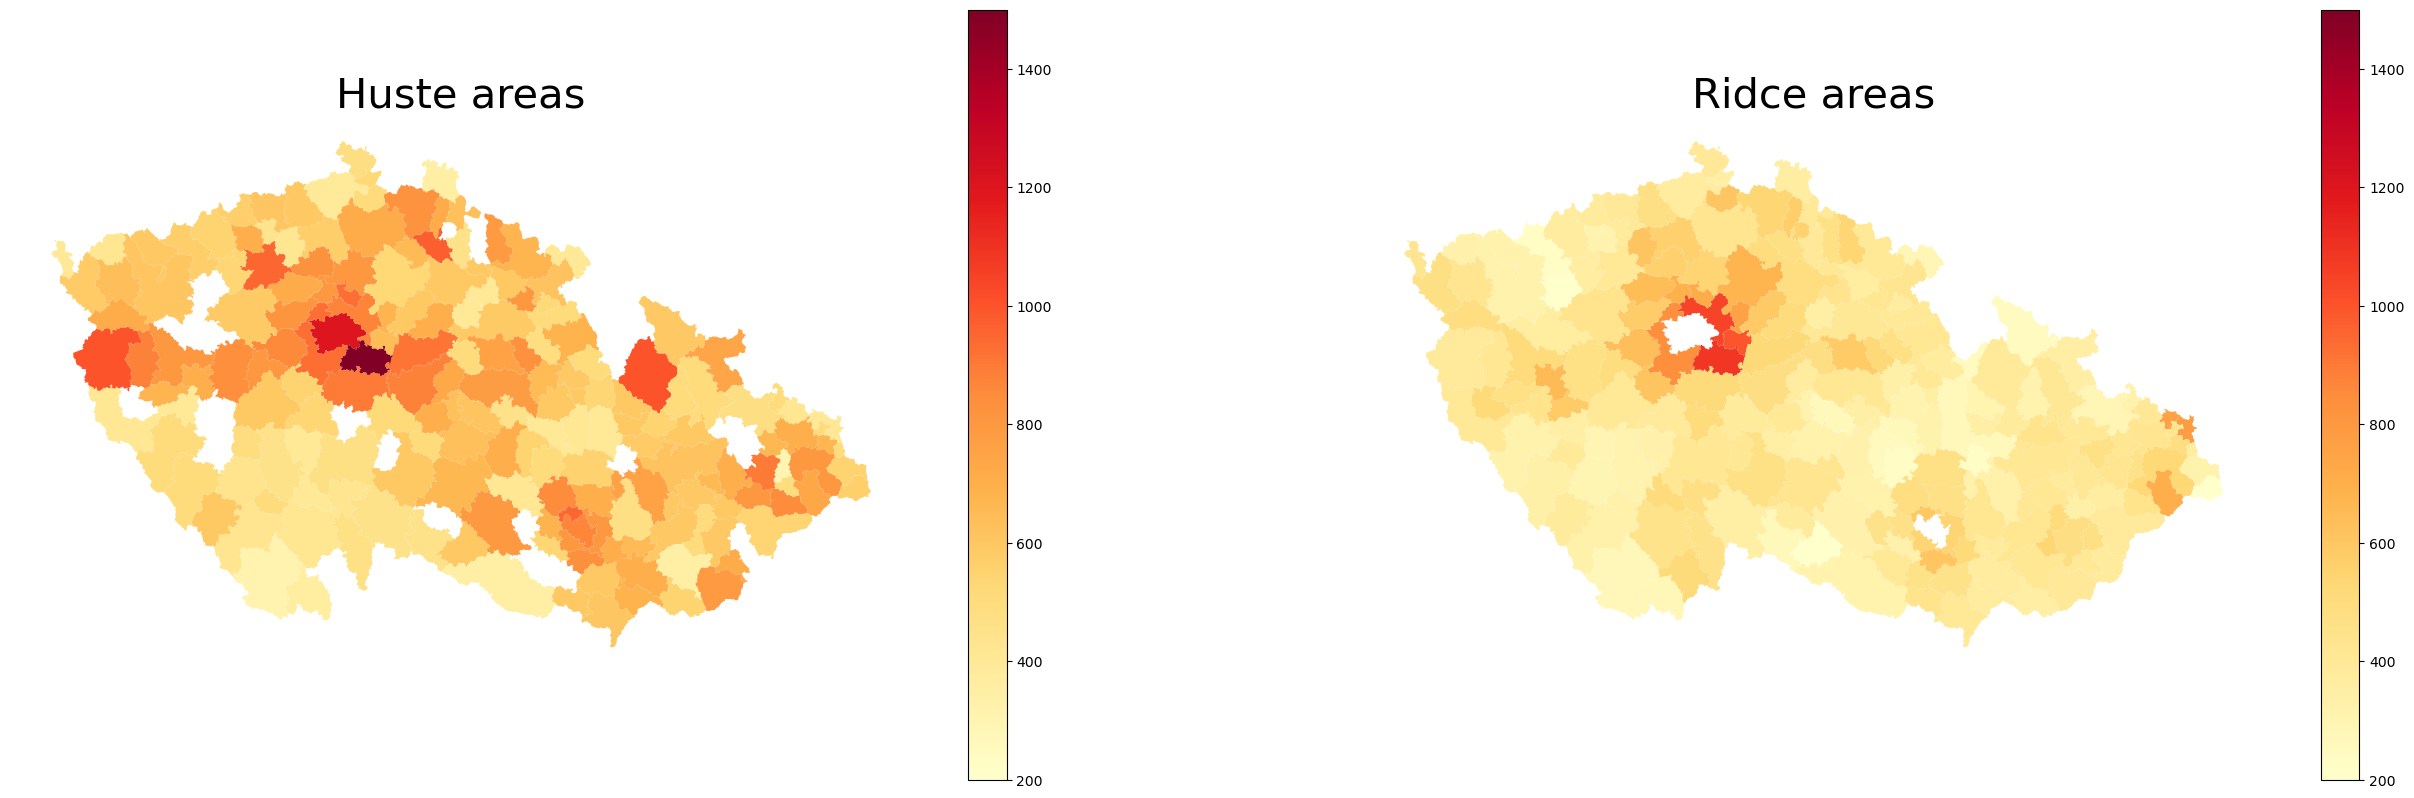

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10))
  
orp_m.plot(
    column="average_m",
    ax=axes[0],
    figsize=(16, 10),
    cmap="YlOrRd",
    vmin=200,
    vmax=1500,
    legend=True)

axes[0].set_title("Huste areas",fontsize=30)
axes[0].set_axis_off()



orp_v.plot(
    column="average_v",
    ax=axes[1],

    figsize=(16, 10),
    vmin=200,
    vmax=1500,
    cmap="YlOrRd",
    legend=True)

axes[1].set_title("Ridce areas",fontsize=30)
axes[1].set_axis_off()

In [197]:
kraj_m = kraje_polygony.merge(table2, left_on ="NAZEV", right_index=True)
kraj_v = kraje_polygony.merge(table4, left_on ="NAZEV", right_index=True)



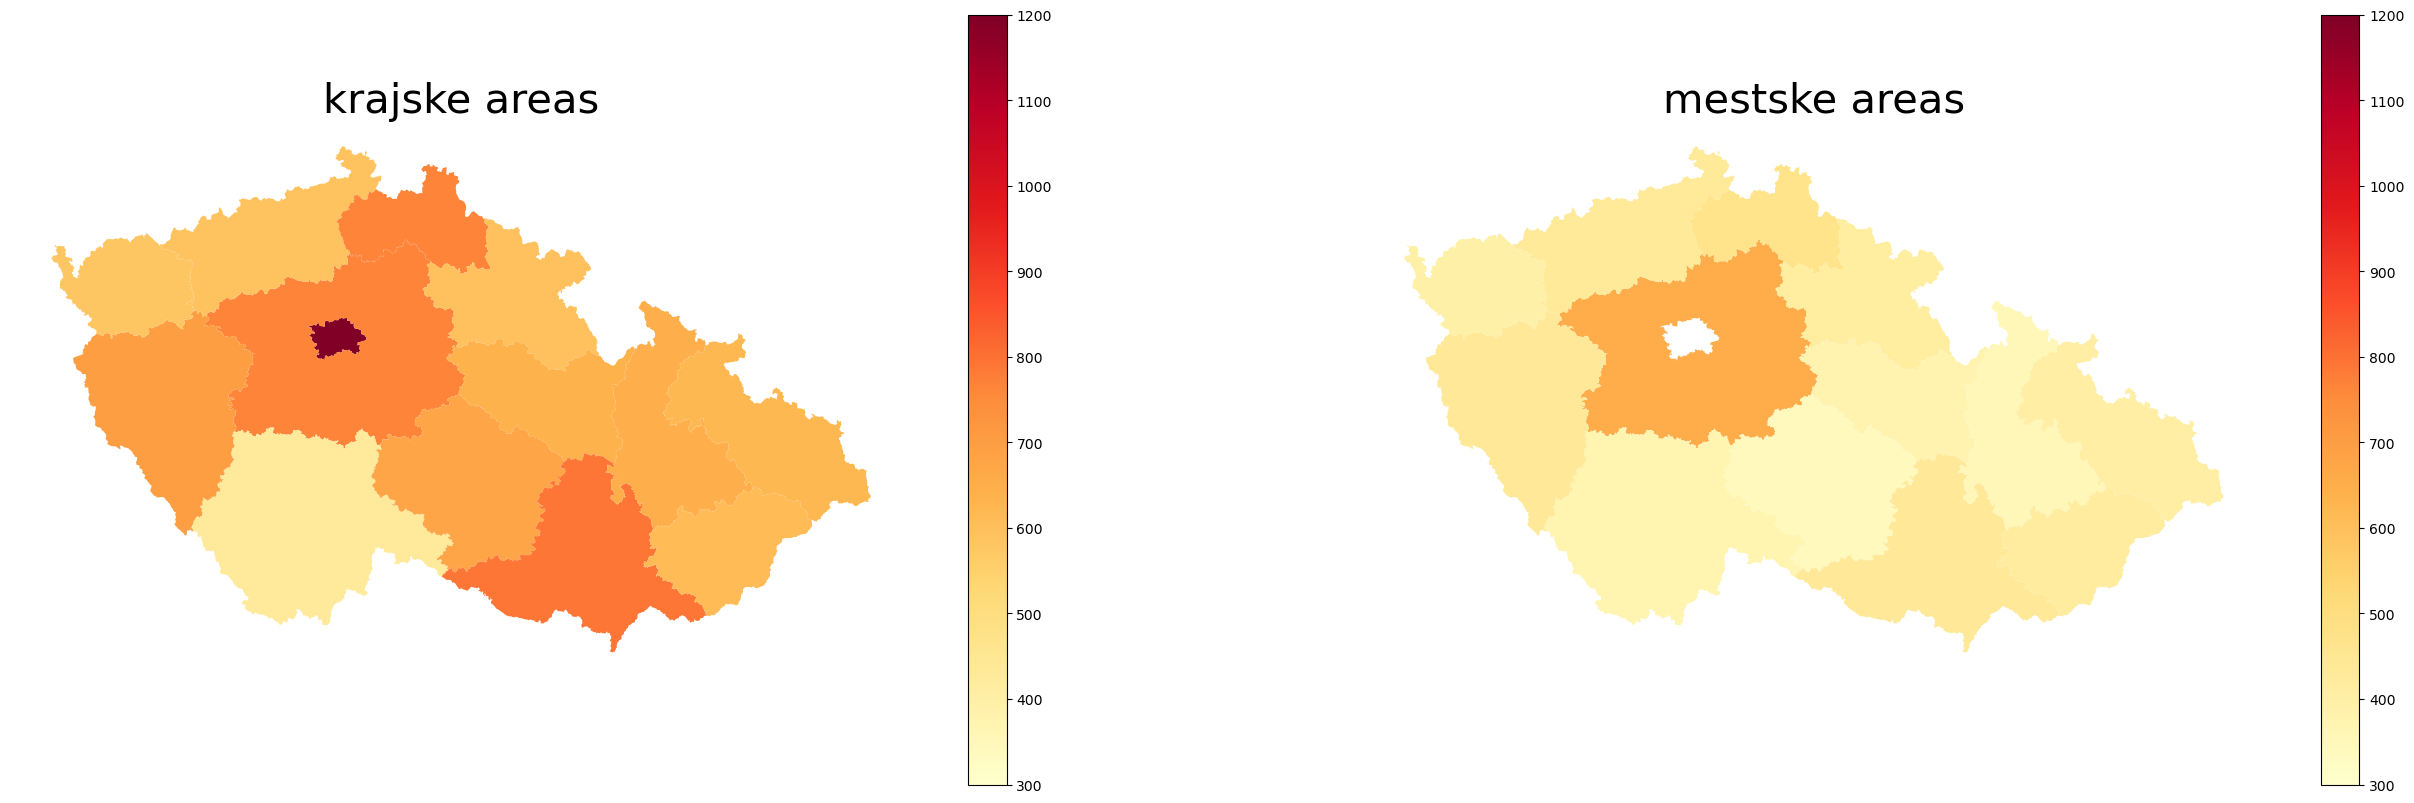

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(32, 10))
  
kraj_m.plot(
    column="average_m",
    ax=axes[0],
    figsize=(16, 10),
    cmap="YlOrRd",
    vmin=300,
    vmax=1200,
    legend=True)

axes[0].set_title("krajske areas",fontsize=30)
axes[0].set_axis_off()

kraj_v.plot(
    column="average_v",
    ax=axes[1],

    figsize=(16, 10),
    vmin=300,
    vmax=1200,
    cmap="YlOrRd",
    legend=True)

axes[1].set_title("mestske areas",fontsize=30)
axes[1].set_axis_off()


In [202]:
kraje_ceny = pd.concat([table1,table3], axis=1)
kraje_ceny= kraje_ceny.drop(columns=(["std_m","std_v"]))

In [203]:
kraje_ceny = kraje_ceny.astype("Int64").T
kraje_ceny.style.background_gradient(axis=1, vmin=400,vmax=1200)

Název_ORP,Aš,Benešov,Beroun,Blansko,Blatná,Bohumín,Boskovice,Brandýs nad Labem-Stará Boleslav,Brno,Broumov,Bruntál,Bučovice,Bystřice nad Pernštejnem,Bystřice pod Hostýnem,Bílina,Bílovec,Břeclav,Cheb,Chomutov,Chotěboř,Chrudim,Dačice,Dobruška,Dobříš,Domažlice,Dvůr Králové nad Labem,Děčín,Frenštát pod Radhoštěm,Frýdek-Místek,Frýdlant,Frýdlant nad Ostravicí,Havlíčkův Brod,Havířov,Hlavní město Praha,Hlinsko,Hlučín,Hodonín,Holešov,Holice,Hořice,Hořovice,Hradec Králové,Hranice,Humpolec,Hustopeče,Ivančice,Jablonec nad Nisou,Jablunkov,Jaroměř,Jeseník,Jihlava,Jindřichův Hradec,Jičín,Kadaň,Kaplice,Karlovy Vary,Karviná,Kladno,Klatovy,Kolín,Kopřivnice,Kostelec nad Orlicí,Kralupy nad Vltavou,Kraslice,Kravaře,Krnov,Kroměříž,Kutná Hora,Kuřim,Kyjov,Lanškroun,Liberec,Lipník nad Bečvou,Litomyšl,Litoměřice,Litovel,Litvínov,Louny,Lovosice,Luhačovice,Lysá nad Labem,Mariánské Lázně,Mikulov,Milevsko,Mladá Boleslav,Mnichovo Hradiště,Mohelnice,Moravská Třebová,Moravské Budějovice,Most,Mělník,Neratovice,Nová Paka,Nové Město na Moravě,Nové Město nad Metují,Nový Bor,Nový Bydžov,Nový Jičín,Nymburk,Náchod,Nýřany,Olomouc,Opava,Orlová,Ostrava,Ostrov,Otrokovice,Pardubice,Pelhřimov,Plzeň,Poděbrady,Polička,Prachatice,Prostějov,Písek,Přelouč,Přerov,Přeštice,Příbram,Rakovník,Rokycany,Rosice,Roudnice nad Labem,Rožnov pod Radhoštěm,Rumburk,Rychnov nad Kněžnou,Rýmařov,Sedlčany,Semily,Slaný,Slavkov u Brna,Soběslav,Sokolov,Stod,Strakonice,Stříbro,Sušice,Svitavy,Světlá nad Sázavou,Tachov,Tanvald,Teplice,Tišnov,Trutnov,Turnov,Tábor,Týn nad Vltavou,Třeboň,Třebíč,Třinec,Uherské Hradiště,Uherský Brod,Uničov,Valašské Meziříčí,Varnsdorf,Velké Meziříčí,Veselí nad Moravou,Vimperk,Vlašim,Vodňany,Vrchlabí,Vsetín,Vysoké Mýto,Vyškov,Zlín,Znojmo,Zábřeh,Ústí nad Labem,Ústí nad Orlicí,Černošice,Česká Lípa,Česká Třebová,České Budějovice,Český Brod,Český Krumlov,Český Těšín,Čáslav,Říčany,Šlapanice,Šternberk,Šumperk,Žamberk,Žatec,Židlochovice,Žďár nad Sázavou,Blovice,Horažďovice,Horšovský Týn,Jilemnice,Konice,Kralovice,Králíky,Moravský Krumlov,Nepomuk,Náměšť nad Oslavou,Odry,Pacov,Podbořany,Pohořelice,Telč,Trhové Sviny,Valašské Klobouky,Vizovice,Votice,Vítkov,Železný Brod
average_m,400,899,857,699,498,400,551,871,866,400,500,657,500,600,435,667,602,583,550,616,779,450,500,550,414,600,392,499,806,350,736,630,669,1205,450,422,686,500,833,400,800,587,700,500,600,534,713,568,800,592,667,449,600,575,367,610,404,817,500,914,304,486,800,420,500,743,593,877,950,704,536,820,662,600,575,581,567,950,420,714,675,718,600,400,528,655,600,400,599,700,800,931,600,546,523,500,400,900,600,617,800,617,484,500,705,600,506,757,600,700,700,400,425,757,449,500,592,400,601,587,844,682,825,850,482,686,500,535,450,716,708,431,633,674,437,877,500,416,700,1000,630,605,850,674,971,471,400,467,799,550,349,791,550,802,525,411,550,600,517,500,794,541,650,479,592,350,600,597,593,927,714,598,420,644,307,500,729,1506,800,600,1000,500,540,836,700,,,,,,,,,,,,,,,,,,,,,
average_v,430,512,635,461,300,758,465,1048,,285,405,381,229,335,378,423,403,472,368,262,412,264,399,613,401,365,371,529,525,361,700,320,489,,352,405,370,501,520,435,492,405,406,343,453,322,571,147,420,249,433,348,487,233,280,317,783,580,320,524,450,469,697,323,321,354,419,481,600,368,269,532,381,311,560,263,381,402,613,402,754,489,443,322,677,496,350,271,114,311,545,721,404,254,371,605,346,430,588,430,508,414,291,425,432,320,535,583,465,653,504,262,329,327,307,483,416,439,400,437,465,464,559,441,396,409,307,387,394,644,519,477,425,468,292,413,337,321,401,383,399,393,488,399,470,416,506,450,326,317,417,396,381,361,344,319,356,382,382,331,533,384,334,420,484,314,303,474,402,842,424,350,444,994,274,360,370,1086,543,442,391,373,359,609,325,582,390,519,467,221,366,248,403,356,452,465,410,204,458,379,512,378,471,500,400,551


In [204]:
print(kraje_ceny)

Název_ORP   Aš  Benešov  Beroun  Blansko  Blatná  Bohumín  Boskovice  \
average_m  400      899     857      699     498      400        551   
average_v  430      512     635      461     300      758        465   

Název_ORP  Brandýs nad Labem-Stará Boleslav  Brno  Broumov  ...  Pacov  \
average_m                               871   866      400  ...   <NA>   
average_v                              1048  <NA>      285  ...    410   

Název_ORP  Podbořany  Pohořelice  Telč  Trhové Sviny  Valašské Klobouky  \
average_m       <NA>        <NA>  <NA>          <NA>               <NA>   
average_v        204         458   379           512                378   

Název_ORP  Vizovice  Votice  Vítkov  Železný Brod  
average_m      <NA>    <NA>    <NA>          <NA>  
average_v       471     500     400           551  

[2 rows x 206 columns]


In [206]:
print((kraje_ceny.iloc[0] > kraje_ceny.iloc[1]).sum())

162


In [208]:
kraje_ceny = pd.concat([table2,table4], axis=1)
kraje_ceny= kraje_ceny.drop(columns=(["std_m","std_v"]))

In [209]:

kraje_ceny = kraje_ceny.astype("Int64").T
kraje_ceny.style.background_gradient(axis=1, vmin=400,vmax=1200)

Kraj,Hlavní město Praha,Jihomoravský kraj,Jihočeský kraj,Karlovarský kraj,Kraj Vysočina,Královéhradecký kraj,Liberecký kraj,Moravskoslezský kraj,Olomoucký kraj,Pardubický kraj,Plzeňský kraj,Středočeský kraj,Zlínský kraj,Ústecký kraj
average_m,1205,791,429,580,676,594,766,621,647,640,700,766,612,591
average_v,,435,371,395,338,416,466,408,354,377,434,655,418,433
